# Графики средних оценок LLM-судьи (gold / noise отдельно)

Единственный источник данных: `results/judge_score_bootstrap_ci.json`.
Пересборка из корня репозитория: `uv run python scripts/build_judge_score_artifacts.py`.

И высота столбца (mean), и полосы ошибок (95% percentile bootstrap ДИ) берутся из одного файла —
методологическая согласованность гарантирована.

Панели 2×2: ось X — **модели**, в каждой группе **два столбца** (baseline и full); у каждой модели свой базовый цвет, внутри группы — **два оттенка** (тусклее → ярче). Легенда — режимы (образец оттенков от средней модели).

PNG (dpi=300) сохраняются в каталог `charts/`: `judge_scores_gold_bootstrap_panel.png`, `judge_scores_noise_bootstrap_panel.png`, `judge_scores_gold_noise_combined_panel.png`.


In [1]:
from __future__ import annotations

import json
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


@dataclass(frozen=True)
class ChartFontSizes:
    tick: int = 12
    axis_label: int = 14
    subplot_title: int = 15
    suptitle: int = 18
    legend: int = 12
    legend_title: int = 13


MODELS: tuple[str, ...] = ("gemma_31", "nemotron", "qwen_35")
MODES: tuple[str, ...] = ("baseline", "full")

# Ключи метрик совпадают с полем "metric" в judge_score_bootstrap_ci.json.
METRICS: tuple[tuple[str, str], ...] = (
    ("relevance", "Релевантность"),
    ("correctness", "Корректность"),
    ("faithfulness", "Достоверность"),
    ("completeness", "Полнота"),
)
CLUSTER_BASE_COLORS: tuple[str, ...] = ("#2a6f97", "#c1666b", "#6a994e")
FONT_SIZES = ChartFontSizes()
BOOTSTRAP_CI_FILENAME = "judge_score_bootstrap_ci.json"

# (model, bench, mode, metric) → (mean, ci_low, ci_high)
BootstrapLookup = dict[tuple[str, str, str, str], tuple[float, float, float]]


def find_repository_root() -> Path:
    """Ищет корень репозитория по наличию results/judge_score_bootstrap_ci.json."""
    here = Path.cwd().resolve()
    for directory in (here, *here.parents):
        if (directory / "results" / BOOTSTRAP_CI_FILENAME).is_file():
            return directory
    raise FileNotFoundError(
        f"Не найден results/{BOOTSTRAP_CI_FILENAME} "
        "— откройте ноутбук из корня репозитория AI_assistant_benchs_public."
    )


def load_bootstrap_ci(path: Path) -> BootstrapLookup:
    """Загрузить bootstrap_ci.json в словарь; записи с nan пропускаются."""
    raw = json.loads(path.read_text(encoding="utf-8"))
    lookup: BootstrapLookup = {}
    for row in raw:
        try:
            key = (str(row["model"]), str(row["bench"]), str(row["mode"]), str(row["metric"]))
            triple = (float(row["mean"]), float(row["ci_low"]), float(row["ci_high"]))
        except (KeyError, TypeError, ValueError):
            continue
        if all(math.isfinite(v) for v in triple):
            lookup[key] = triple
    return lookup


def model_legend_label(model: str) -> str:
    """Подпись модели для легенды (без одиночных цифр как отдельных токенов)."""
    parts = [piece for piece in model.replace("_", " ").split() if not piece.isdigit()]
    return " ".join(parts) if parts else model.replace("_", " ")


def shades_for_cluster(hex_base: str, modes: tuple[str, ...]) -> tuple[str, ...]:
    """Оттенки одного цвета: от приглушённого к насыщенному; число шагов = len(modes)."""
    base = np.asarray(mcolors.to_rgb(hex_base), dtype=np.float64)
    num_modes = len(modes)
    if num_modes <= 0:
        return ()
    if num_modes == 1:
        return (mcolors.rgb2hex(tuple(np.clip(base, 0.0, 1.0))),)
    dim = np.clip(
        0.58 * base + 0.42 * np.array([0.78, 0.78, 0.80], dtype=np.float64),
        0.0,
        1.0,
    )
    hex_colors: list[str] = []
    for step_index in range(num_modes):
        blend = step_index / (num_modes - 1)
        rgb = np.clip((1.0 - blend) * dim + blend * base, 0.0, 1.0)
        hex_colors.append(mcolors.rgb2hex(tuple(rgb)))
    return tuple(hex_colors)


def fixed_score_axis_limits() -> tuple[float, float]:
    """Фиксированный масштаб оси Y 4.5–5.0 для барчартов (оценки 1–5)."""
    return 4.5, 5.0




In [2]:
class JudgeScoresBarCharts:
    """Загрузка bootstrap CI и построение панелей графиков.

    Единственный источник данных — judge_score_bootstrap_ci.json.
    И высота столбца (mean), и полосы ошибок (ci_low, ci_high) берутся
    из одного и того же поля записи — нет рассогласования методологий.
    """

    def __init__(
        self,
        *,
        project_root: Path,
        ci_lookup: BootstrapLookup,
        font_sizes: ChartFontSizes = FONT_SIZES,
    ) -> None:
        self._project_root = project_root.resolve()
        self._ci = ci_lookup
        self._font_sizes = font_sizes
        self._charts_dir = self._project_root / "charts"
        self._charts_dir.mkdir(parents=True, exist_ok=True)

    @classmethod
    def from_repository(cls) -> JudgeScoresBarCharts:
        root = find_repository_root()
        path = root / "results" / BOOTSTRAP_CI_FILENAME
        ci_lookup = load_bootstrap_ci(path)
        print("JSON:", path)
        print("Записей:", len(ci_lookup))
        return cls(project_root=root, ci_lookup=ci_lookup)

    def _entry(self, model: str, bench: str, mode: str, metric: str) -> tuple[float, float, float] | None:
        """Тройка (mean, ci_low, ci_high) из lookup или None."""
        return self._ci.get((model, bench, mode, metric))

    def plot_bench_four_figures_panel(
        self,
        *,
        title_prefix: str,
        bench: str,
        file_stem: str,
    ) -> None:
        """Фигура 2×2: четыре метрики, ось X — модели, два режима на группу модели."""
        x_positions = np.arange(len(MODELS))
        num_modes = len(MODES)
        bar_width = 0.22
        offsets = np.linspace(
            -(num_modes - 1) / 2 * bar_width,
            (num_modes - 1) / 2 * bar_width,
            num_modes,
        )
        band_half_width = bar_width * 0.58
        axis_min, axis_max = fixed_score_axis_limits()

        figure, axes = plt.subplots(2, 2, figsize=(14.5, 10.5))
        axes_flat = axes.flatten()
        for axis_index, (metric, metric_label) in enumerate(METRICS):
            axis = axes_flat[axis_index]
            for mode_index, mode in enumerate(MODES):
                offset = offsets[mode_index]
                bar_heights = [
                    entry[0] if (entry := self._entry(model, bench, mode, metric)) is not None else float("nan")
                    for model in MODELS
                ]
                bar_colors = [
                    shades_for_cluster(CLUSTER_BASE_COLORS[mi], MODES)[mode_index]
                    for mi in range(len(MODELS))
                ]
                axis.bar(
                    x_positions + offset,
                    bar_heights,
                    bar_width,
                    color=bar_colors,
                    edgecolor="white",
                    linewidth=0.6,
                    zorder=2,
                )
            for mode_index, mode in enumerate(MODES):
                offset = offsets[mode_index]
                for mi, model in enumerate(MODELS):
                    entry = self._entry(model, bench, mode, metric)
                    if entry is None:
                        continue
                    _, low, high = entry
                    x_center = float(x_positions[mi] + offset)
                    face_color = shades_for_cluster(CLUSTER_BASE_COLORS[mi], MODES)[mode_index]
                    axis.fill_betweenx(
                        [low, high],
                        x_center - band_half_width,
                        x_center + band_half_width,
                        facecolor=face_color,
                        edgecolor="white",
                        linewidth=0.9,
                        alpha=0.5,
                        zorder=6,
                    )
            axis.set_xticks(x_positions, [model_legend_label(m) for m in MODELS])
            axis.tick_params(axis="both", which="major", labelsize=self._font_sizes.tick)
            axis.set_xlabel("Модель", fontsize=self._font_sizes.axis_label)
            axis.set_ylabel("Средняя оценка (1–5)", fontsize=self._font_sizes.axis_label)
            axis.set_title(metric_label, fontsize=self._font_sizes.subplot_title)
            axis.set_ylim(axis_min, axis_max)
            axis.grid(axis="y", alpha=0.35)
            axis.set_axisbelow(True)

        legend_model_index = len(MODELS) // 2
        legend_handles = [
            Patch(
                facecolor=shades_for_cluster(CLUSTER_BASE_COLORS[legend_model_index], MODES)[mi],
                edgecolor="white",
                linewidth=0.6,
                label=MODES[mi].capitalize(),
            )
            for mi in range(len(MODES))
        ]
        if title_prefix.strip():
            figure.suptitle(title_prefix, fontsize=self._font_sizes.suptitle, y=1.02)
        figure.legend(
            handles=legend_handles,
            title="Режим",
            ncol=len(MODES),
            loc="lower center",
            bbox_to_anchor=(0.5, -0.06),
            framealpha=0.95,
            fontsize=self._font_sizes.legend,
            title_fontsize=self._font_sizes.legend_title,
        )
        top_margin = 0.96 if title_prefix.strip() else 1.0
        figure.tight_layout(rect=(0.0, 0.11, 1.0, top_margin))
        output_path = self._charts_dir / f"{file_stem}_panel.png"
        figure.savefig(output_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(figure)
        print("Сохранено:", output_path)

    def plot_bench_two_benches_panel_four_figures(
        self,
        *,
        title_prefix: str,
        file_stem: str,
    ) -> None:
        """Фигура 2×2: gold и noise рядом, режим full, ось X — тип бенча."""
        mode = "full"
        benches = ("gold", "noise")
        bench_tick_labels = ("Без шума", "С шумом")
        bench_centers = np.arange(len(benches), dtype=float)
        num_models = len(MODELS)
        bar_width = 0.22
        offsets = np.linspace(
            -(num_models - 1) / 2 * bar_width,
            (num_models - 1) / 2 * bar_width,
            num_models,
        )
        band_half_width = bar_width * 0.58
        axis_min, axis_max = 4.6, 5.0

        figure, axes = plt.subplots(2, 2, figsize=(13.0, 10.0))
        axes_flat = axes.ravel()
        legend_handles_labels: tuple | None = None

        for panel_index, (axis, (metric, metric_label)) in enumerate(zip(axes_flat, METRICS)):
            for bench_index, bench in enumerate(benches):
                center = float(bench_centers[bench_index])
                for offset, model, color in zip(offsets, MODELS, CLUSTER_BASE_COLORS):
                    entry = self._entry(model, bench, mode, metric)
                    bar_height = entry[0] if entry is not None else float("nan")
                    label = model_legend_label(model) if bench_index == 0 else "_nolegend_"
                    axis.bar(
                        [center + offset],
                        [bar_height],
                        bar_width,
                        label=label,
                        color=color,
                        edgecolor="white",
                        linewidth=0.6,
                        zorder=2,
                    )
            for bench_index, bench in enumerate(benches):
                center = float(bench_centers[bench_index])
                for offset, model, color in zip(offsets, MODELS, CLUSTER_BASE_COLORS):
                    entry = self._entry(model, bench, mode, metric)
                    if entry is None:
                        continue
                    _, low, high = entry
                    x_center = center + offset
                    axis.fill_betweenx(
                        [low, high],
                        x_center - band_half_width,
                        x_center + band_half_width,
                        facecolor=color,
                        edgecolor="white",
                        linewidth=0.9,
                        alpha=0.5,
                        zorder=6,
                    )
            if legend_handles_labels is None:
                legend_handles_labels = axis.get_legend_handles_labels()
            axis.set_xticks(bench_centers, bench_tick_labels)
            axis.tick_params(axis="both", which="major", labelsize=self._font_sizes.tick)
            if panel_index >= 2:
                axis.set_xlabel("Бенчмарк", fontsize=self._font_sizes.axis_label)
            if panel_index % 2 == 0:
                axis.set_ylabel("Средняя оценка (1–5)", fontsize=self._font_sizes.axis_label)
            axis.set_title(metric_label, fontsize=self._font_sizes.subplot_title)
            axis.set_ylim(axis_min, axis_max)
            axis.grid(axis="y", alpha=0.35)
            axis.set_axisbelow(True)

        if legend_handles_labels is not None:
            handles, labels = legend_handles_labels
            figure.legend(
                handles,
                labels,
                title="Модель",
                ncol=3,
                loc="lower center",
                bbox_to_anchor=(0.5, 0.02),
                bbox_transform=figure.transFigure,
                framealpha=0.92,
                fontsize=self._font_sizes.legend,
                title_fontsize=self._font_sizes.legend_title,
            )
        if title_prefix.strip():
            figure.suptitle(title_prefix, fontsize=self._font_sizes.suptitle, y=1.01)
        figure.tight_layout(rect=(0.0, 0.10, 1.0, 0.96))
        output_path = self._charts_dir / f"{file_stem}.png"
        figure.savefig(output_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(figure)
        print("Сохранено:", output_path)


charts = JudgeScoresBarCharts.from_repository()


JSON: /mnt/ssd2/Semestr_4/Master_thesis/AI_assistant_benchs_public/results/judge_score_bootstrap_ci.json
Записей: 48


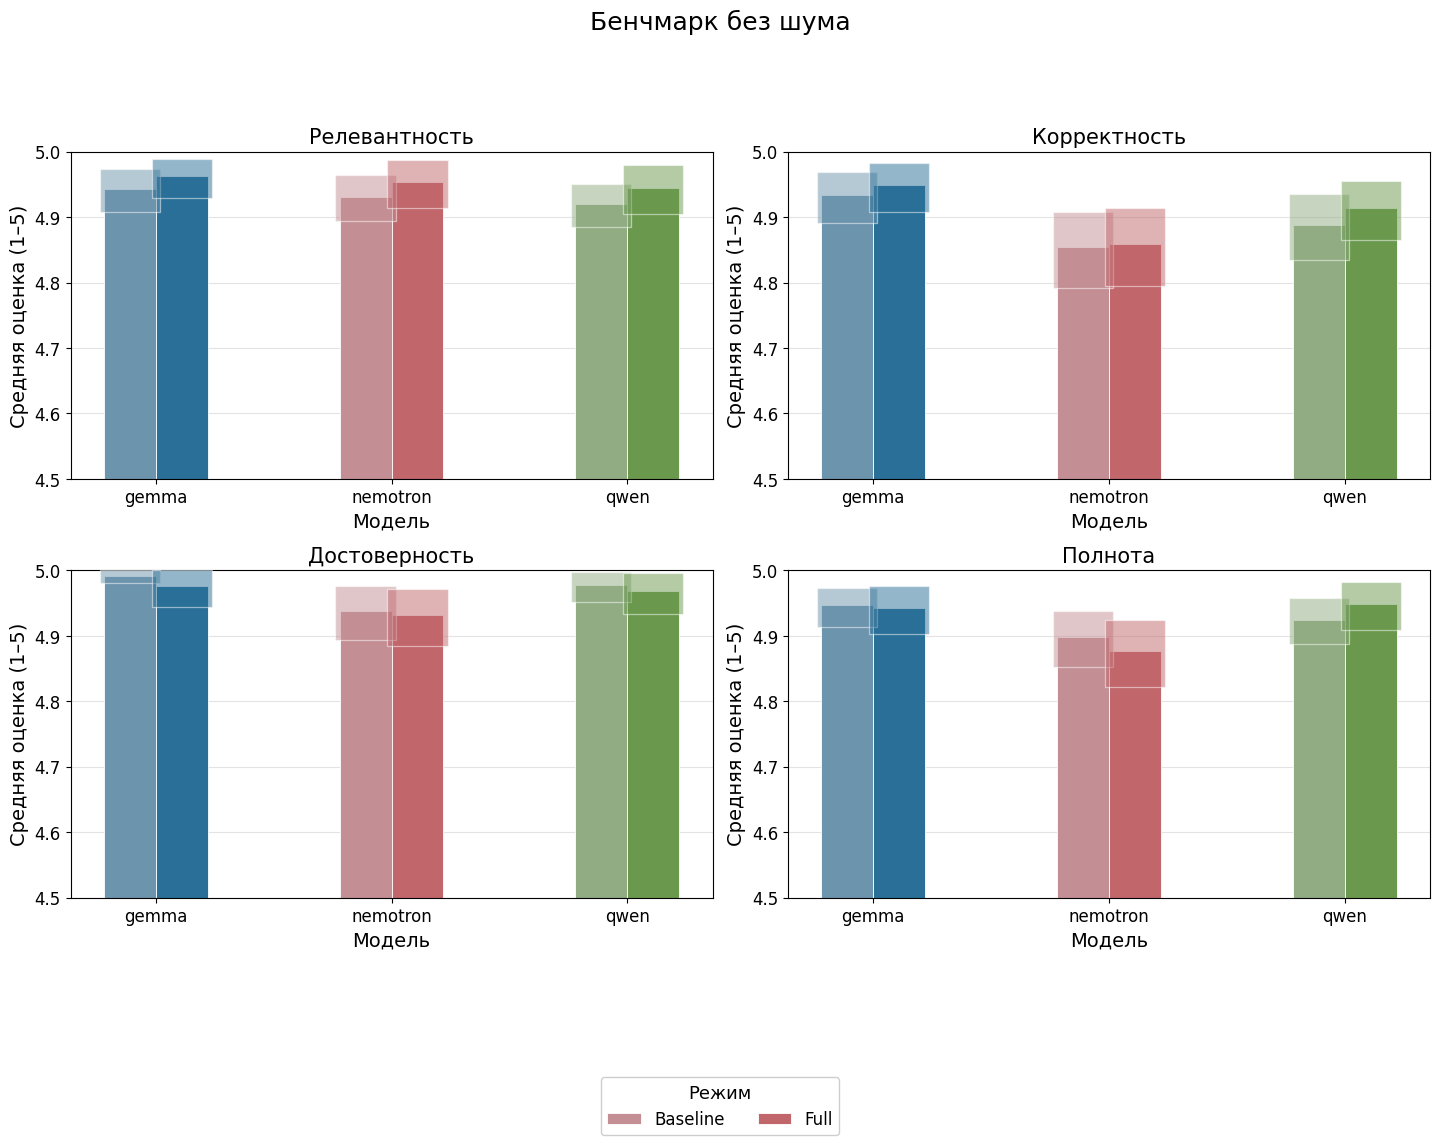

Сохранено: /mnt/ssd2/Semestr_4/Master_thesis/AI_assistant_benchs_public/charts/judge_scores_gold_bootstrap_panel.png


In [3]:
charts.plot_bench_four_figures_panel(
    title_prefix="Бенчмарк без шума",
    bench="gold",
    file_stem="judge_scores_gold_bootstrap",
)


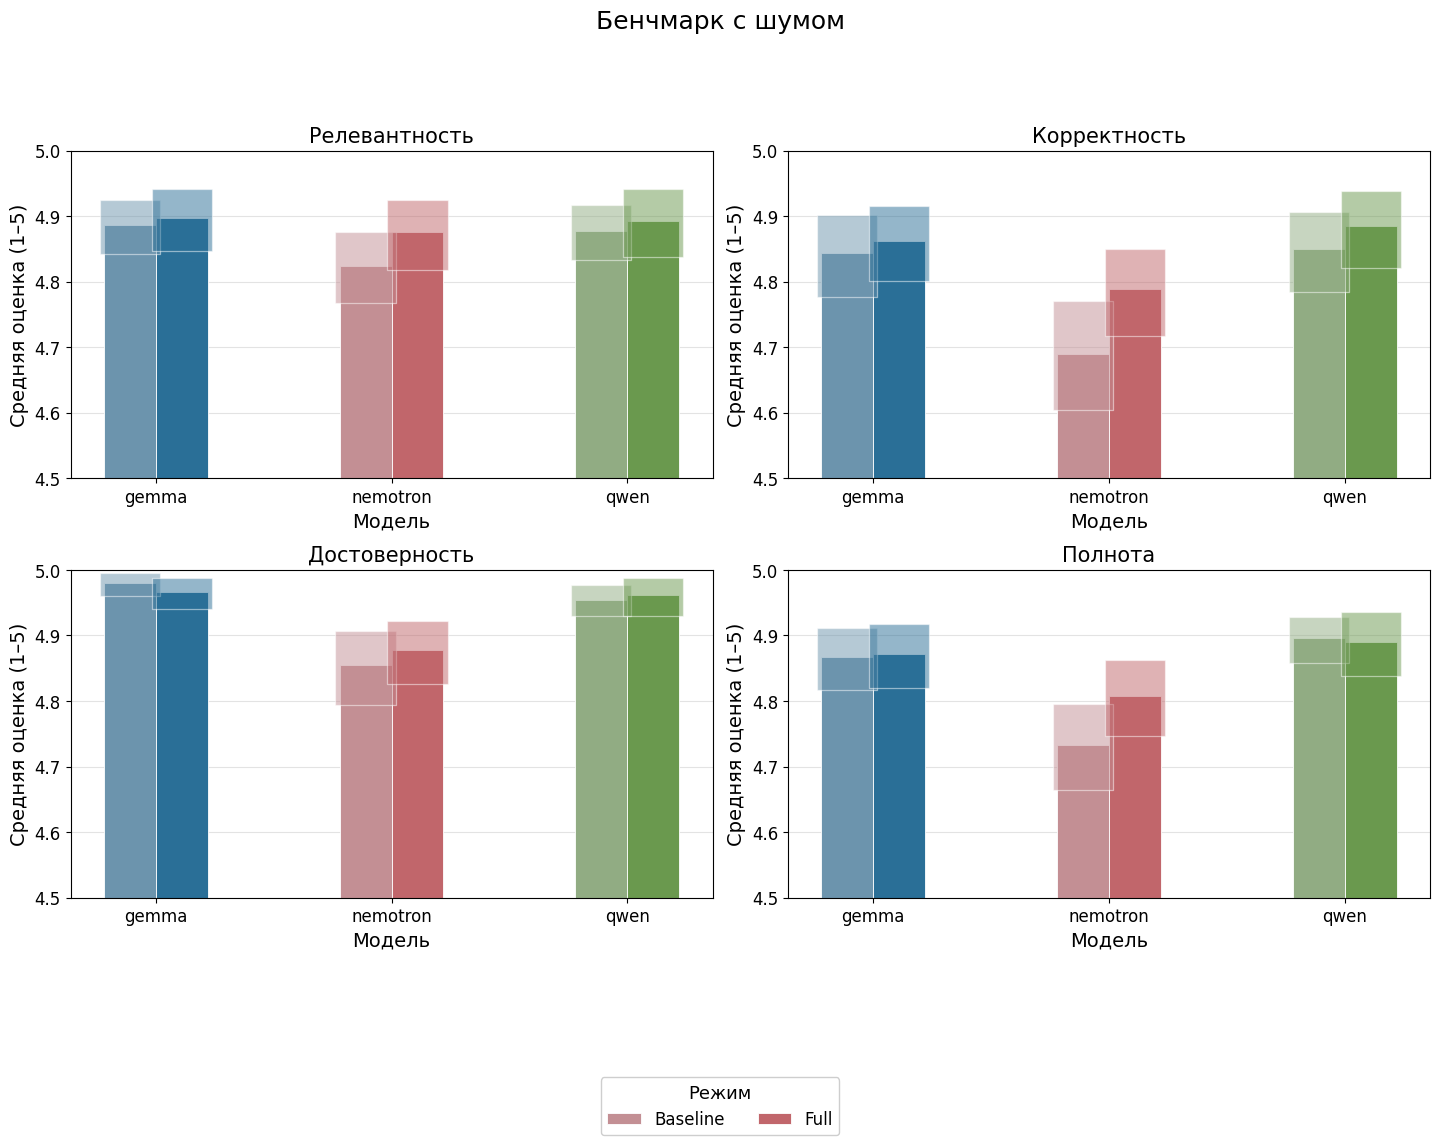

Сохранено: /mnt/ssd2/Semestr_4/Master_thesis/AI_assistant_benchs_public/charts/judge_scores_noise_bootstrap_panel.png


In [4]:
charts.plot_bench_four_figures_panel(
    title_prefix="Бенчмарк с шумом",
    bench="noise",
    file_stem="judge_scores_noise_bootstrap",
)


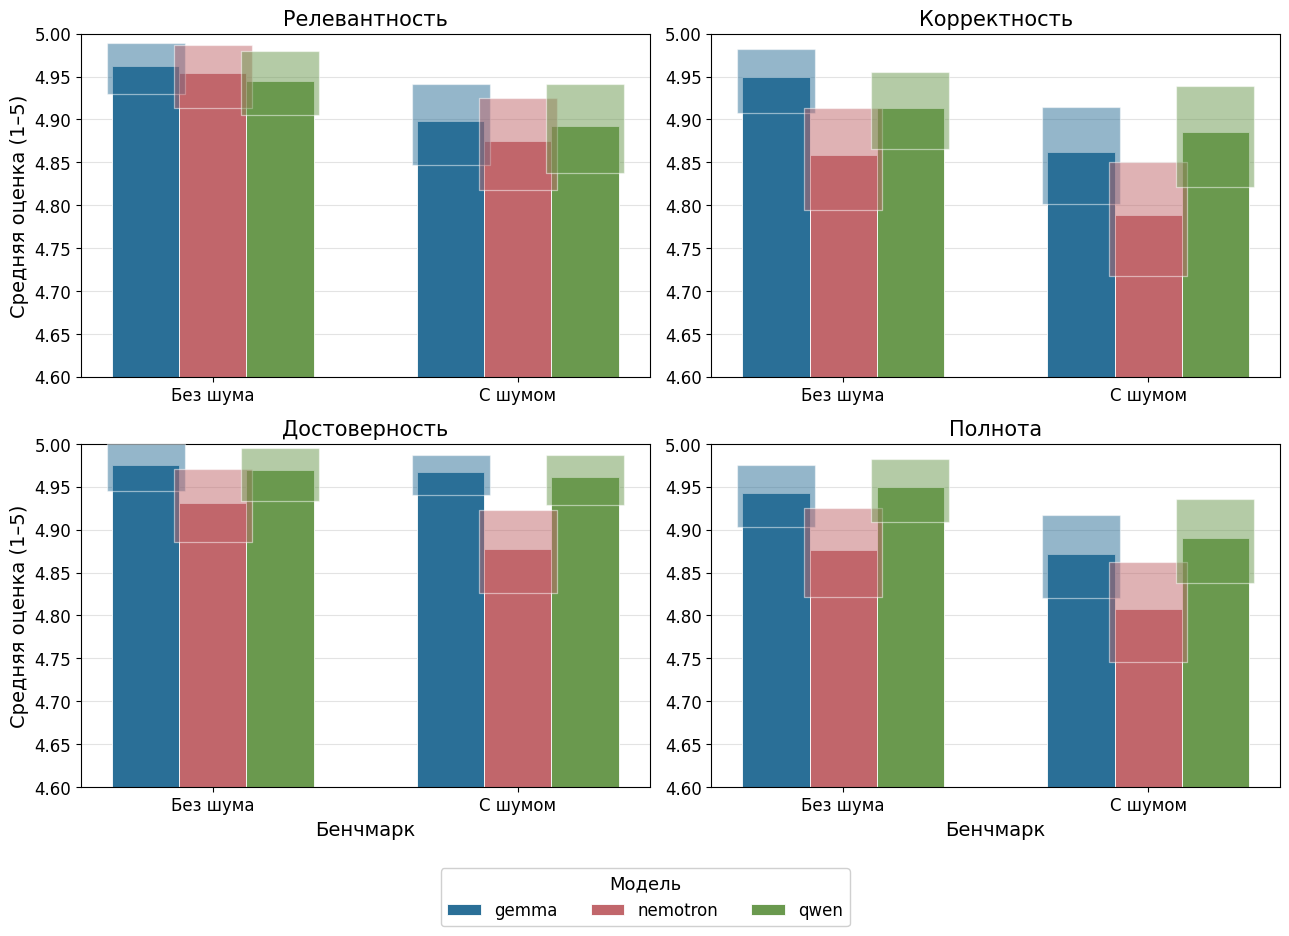

Сохранено: /mnt/ssd2/Semestr_4/Master_thesis/AI_assistant_benchs_public/charts/judge_scores_gold_noise_combined_panel.png


In [5]:
charts.plot_bench_two_benches_panel_four_figures(
    title_prefix="",
    file_stem="judge_scores_gold_noise_combined_panel",
)
